# Anàlise de Preços Internacionais de Combustíveis

Este projeto analisa a evolução dos preços da gasolina entre 1990 e 2008 em diversos paises, ultilizando python e a biblioteca pandas.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt 

print("ferramenta carregada com sucesso!")

ferramenta carregada com sucesso!


In [21]:
dados= pd.read_csv('gas_prices.csv')
df

,Year,Australia,Canada,France,Germany,Italy,Japan,Mexico,South Korea,UK,USA
0,1990,NaN,1.87,3.63,2.65,4.59,3.16,1.00,2.05,2.82,1.16
1,1991,1.96,1.92,3.45,2.90,4.50,3.46,1.30,2.49,3.01,1.14
2,1992,1.89,1.73,3.56,3.27,4.53,3.58,1.50,2.65,3.06,1.13
3,1993,1.73,1.57,3.41,3.07,3.68,4.16,1.56,2.88,2.84,1.11
4,1994,1.84,1.45,3.59,3.52,3.70,4.36,1.48,2.87,2.99,1.11
5,1995,1.95,1.53,4.26,3.96,4.00,4.43,1.11,2.94,3.21,1.15
6,1996,2.12,1.61,4.41,3.94,4.39,3.64,1.25,3.18,3.34,1.23
7,1997,2.05,1.62,4.00,3.53,4.07,3.26,1.47,3.34,3.83,1.23
8,1998,1.63,1.38,3.87,3.34,3.84,2.82,1.49,3.04,4.06,1.06
9,1999,1.72,1.52,3.85,3.42,3.87,3.27,1.79,3.80,4.29,1.17


In [27]:
# 1. Filtramos apenas a linha do ano de 2008
dados_2008 = df[df['Year'] == 2008]

# 2. Como o ano não é um preço, vamos removê-lo da comparação temporariamente
precos_2008 = dados_2008.drop(columns=['Year'])

# 3. Transpomos (viramos) os dados para facilitar a ordenação e pegamos os 3 maiores
top_3_2008 = precos_2008.T.squeeze().sort_values(ascending=False).head(3)

print("Os 3 países que pagaram mais caro pela gasolina em 2008 foram:")
print(top_3_2008)

Os 3 países que pagaram mais caro pela gasolina em 2008 foram:
Germany    7.75
Italy      7.63
France     7.51
Name: 18, dtype: float64


In [28]:
# 1. Reutilizamos o filtro de 2008 (ou usamos o que já criamos)
dados_2008 = df[df['Year'] == 2008]
precos_2008 = dados_2008.drop(columns=['Year'])

# 2. Agora ordenamos do MENOR para o MAIOR (ascending=True)
# O head(3) agora vai pegar os 3 mais baratos
top_3_baratos_2008 = precos_2008.T.squeeze().sort_values(ascending=True).head(3)

print("Os 3 países com a gasolina mais barata em 2008 foram:")
print(top_3_baratos_2008)

Os 3 países com a gasolina mais barata em 2008 foram:
Mexico    2.45
USA       3.27
Canada    4.08
Name: 18, dtype: float64


In [33]:
# 1. Filtramos o ano de 2002 e limpamos a coluna Year
dados_2002 = df[df['Year'] == 2002].set_index('Year').T.iloc[:, 0]

# 2. Encontramos os valores e os nomes dos países
maior_valor = dados_2002.max()
menor_valor = dados_2002.min()

pais_maior = dados_2002.idxmax()
pais_menor = dados_2002.idxmin()

# 3. Resposta formatada
print(f"No ano de 2002, o país {pais_menor} teve o menor valor, custando {menor_valor}.")
print(f"No ano de 2002, o país {pais_maior} teve o maior valor, custando {maior_valor}.")

No ano de 2002, o país USA teve o menor valor, custando 1.36.
No ano de 2002, o país UK teve o maior valor, custando 4.16.


## Visualização Gráfica

Abaixo, apresento um gráfico comparativo para visualizar a tendência de preços nos Alemanha,México e Coreia do Sul.

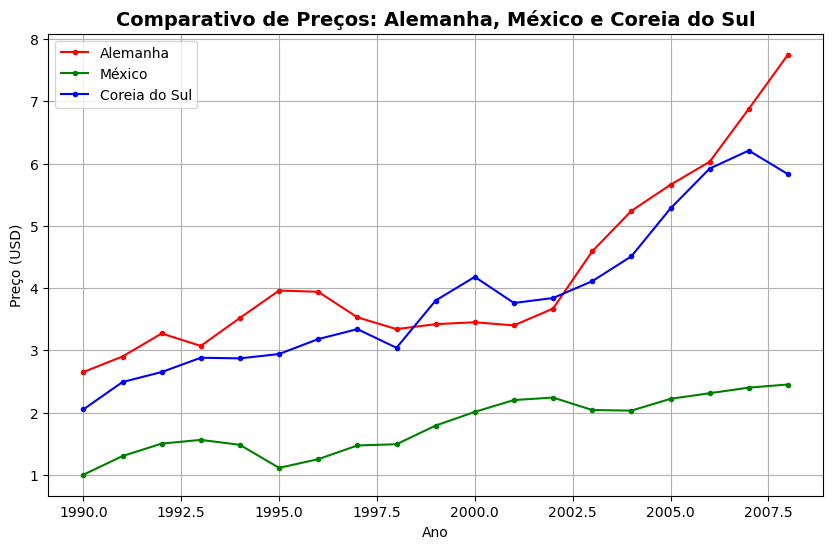

In [37]:
plt.figure(figsize=(10, 6))
plt.title('Comparativo de Preços: Alemanha, México e Coreia do Sul', fontdict={'fontweight':'bold', 'fontsize': 14})

# Plotando os novos países
# Lembre-se: usamos o nome da coluna em inglês para o código encontrar os dados
plt.plot(df.Year, df.Germany, 'r.-', label='Alemanha')
plt.plot(df.Year, df.Mexico, 'g.-', label='México')
plt.plot(df.Year, df['South Korea'], 'b.-', label='Coreia do Sul') # Usamos aspas porque tem espaço no nome

plt.xlabel('Ano')
plt.ylabel('Preço (USD)')
plt.legend()
plt.grid(True)

plt.show()

## Conclusão 
Enquanto os países desenvolvidos (Alemanha e Coreia) mostram maior volatilidade e preços altos,o México Destaca-se pela estabilidade dos preços (uma linha mais "reta" em alguns períodos).
